# STEP 2 · 轨迹 → SoC → 低电量需求
在开头选择 `CITY`、`CITY_CONFIG` 和 `MODE`。本 notebook 从当前城市轨迹重建能耗和 SoC，找每辆车每个放电周期首次跌破 20% 的点，并按约 1km 栅格聚合成**低电量事件频率**。


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'      # 城市配置键；全国城市可改成 'shenzhen' 等
CITY_CONFIG = ''        # 可选：外部 city_configs.json 路径，例如 r'../city_configs.json'
MODE = 'truncated'      # 'truncated' 或 'comprehensive'
NOTEBOOK_SMOKE = False  # True 时减少抽样和候选规模，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
print(f'当前城市：{cso.CITY_NAME} ({cso.CITY}) | 口径：{MODE} | 抽样次数：{DRAWS}')


当前城市：广州 (guangzhou) | 口径：truncated | 抽样次数：40


## 2.1 代表车的 SoC 曲线（按一天总耗电的 30/50/70/90 分位选车）
横轴是该车一天累计行驶里程，纵轴 SoC；跌破 20% 即触发一次低电量需求。


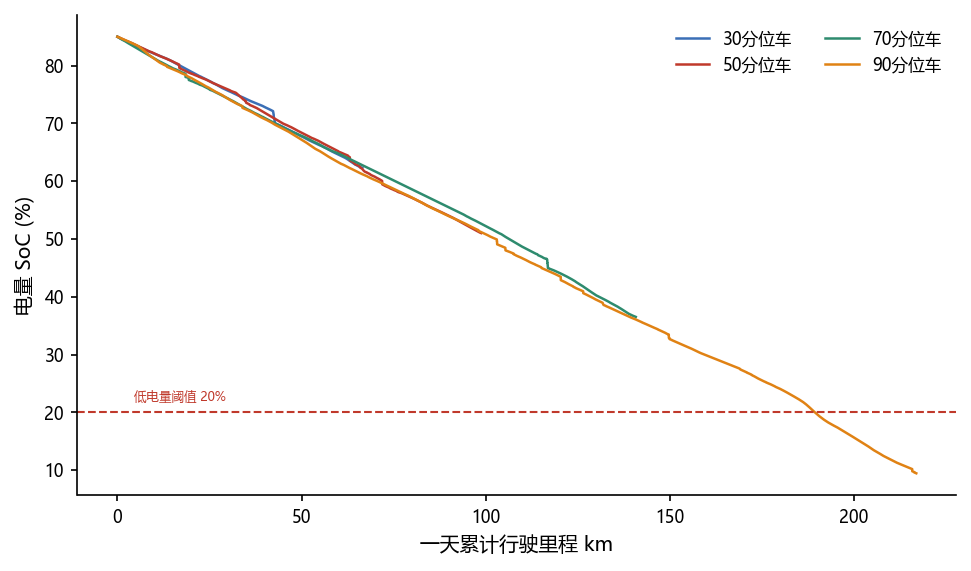

In [2]:
curves=cso.example_soc_curves((30,50,70,90))
fig,ax=plt.subplots(figsize=style.mm(120,66))
for cc in curves:
    ax.plot(cc['cum_km'],cc['soc']*100,lw=1.2,label=f"{cc['pct']}分位车")
ax.axhline(cso.SOC_LOW*100,color=style.C['red'],ls='--',lw=1); ax.text(ax.get_xlim()[1]*.02,cso.SOC_LOW*100+2,'低电量阈值 20%',color=style.C['red'],fontsize=6)
ax.set_xlabel('一天累计行驶里程 km'); ax.set_ylabel('电量 SoC (%)'); ax.legend(ncol=2); plt.show()


## 2.2 期望低电量需求面
$w_i$ = 第 i 个 1km 格子**一天发生低电量事件的期望次数**（对初始电量蒙特卡洛抽样取平均），是计数/频率，不是连续场。下面左图是 $w_i$ 的频次直方图，右图是空间分布。


需求格 3336 个 | 期望低电量事件合计 4489 次/天


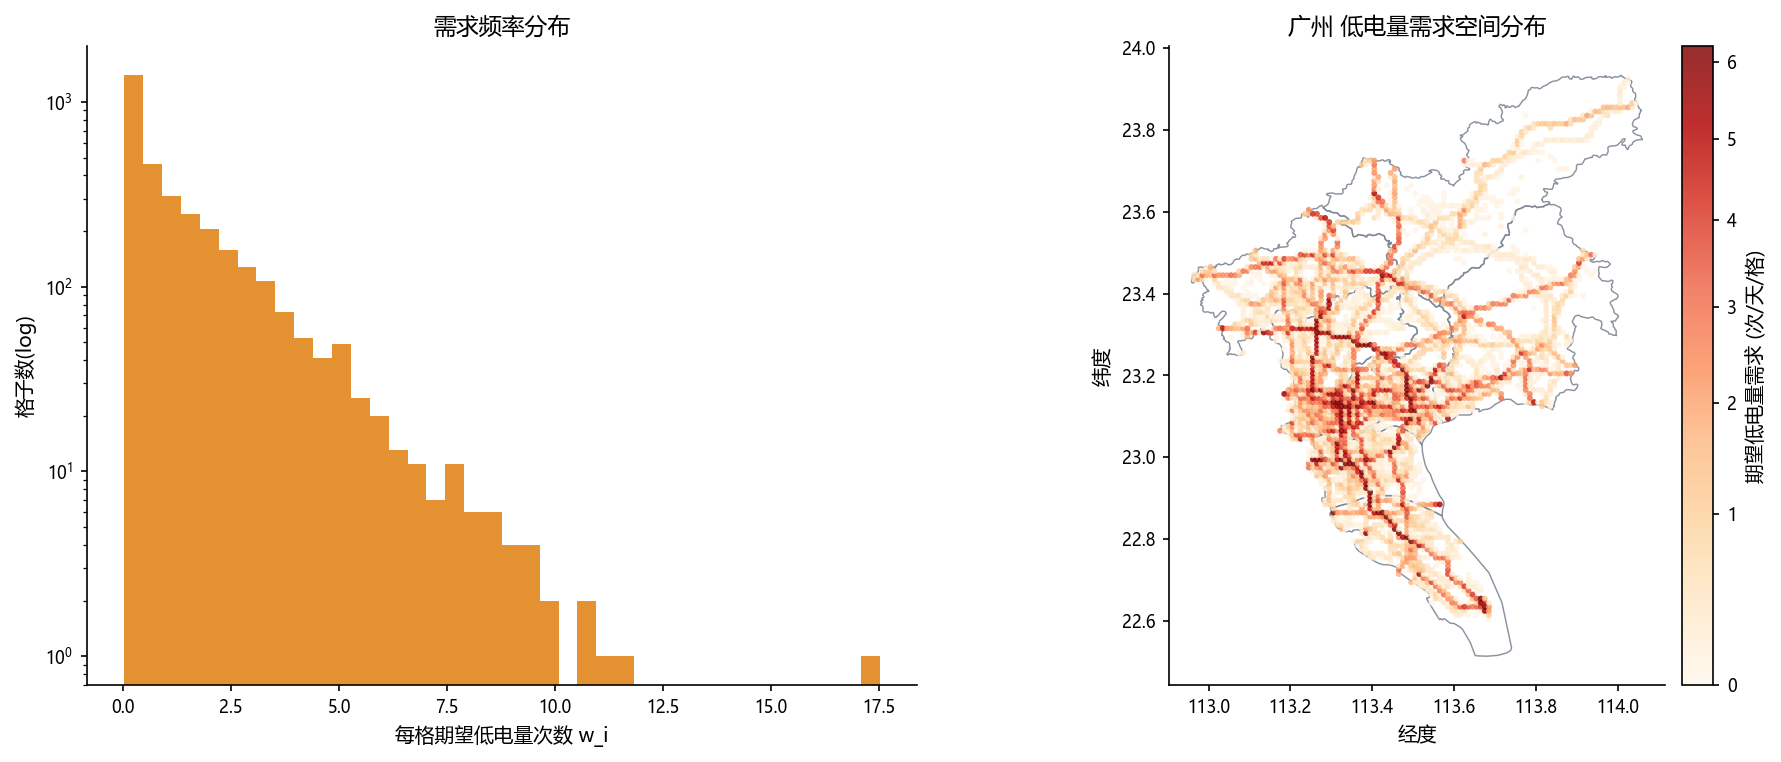

In [3]:
def demand_norm(w):
    m = w > 0
    vmax = float(np.percentile(w[m], 98)) if np.any(m) else 1.0
    return mcolors.PowerNorm(gamma=0.72, vmin=0.0, vmax=max(vmax, 1e-9))

D = cso.demand_surface(draws=DRAWS)
w = D['w']
print(f'需求格 {D["n_cells"]} 个 | 期望低电量事件合计 {w.sum():.0f} 次/天')
fig, ax = plt.subplots(1, 2, figsize=style.mm(190, 82))
ax[0].hist(w, bins=40, color=style.C['orange'], alpha=.88)
ax[0].set_yscale('log')
ax[0].set_xlabel('每格期望低电量次数 w_i')
ax[0].set_ylabel('格子数(log)')
ax[0].set_title('需求频率分布')
style.draw_admin(ax[1], cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE, color='#7E8795', lw=0.7)
m = w > 0
sc = ax[1].scatter(D['lon_c'][m], D['lat_c'][m], c=w[m], s=8, cmap=style.SEQ,
                   norm=demand_norm(w), alpha=.82, linewidths=0)
fig.colorbar(sc, ax=ax[1], fraction=0.04, pad=0.02, label='期望低电量需求 (次/天/格)')
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_title(f'{cso.CITY_NAME} 低电量需求空间分布')
ax[1].set_xlabel('经度')
ax[1].set_ylabel('纬度')
plt.tight_layout()
plt.show()
